In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

In [2]:
data1 = pd.read_excel('fabryperot exp1.xlsx',"Sheet2",skiprows=2)

In [3]:
print(data1.columns)

Index(['n', 'm', 'left side (mm)', 'right side (mm)', 'Diameter', 'radius',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12'],
      dtype='object')


In [4]:
n_arr = data1['n'][1:].to_numpy()
radius_arr = data1['radius'][1:].to_numpy()
sqr_rad_arr = radius_arr**2 -  data1['radius'][0]**2

In [5]:
def stLine(x, p1, p2):
    return p1 * x + p2

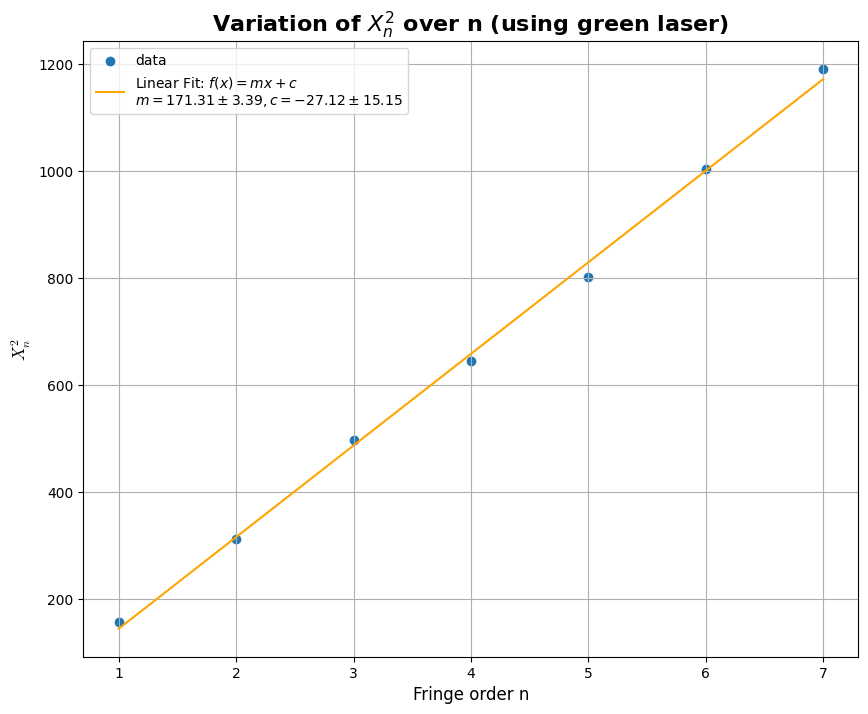

In [6]:
plt.figure(figsize = (10,8))
plt.scatter(n_arr,sqr_rad_arr, label = "data")
params, pcov = curve_fit(stLine,n_arr,sqr_rad_arr)
perr = np.sqrt(np.diag(pcov))
plt.plot(
    n_arr,
    stLine(n_arr, *params),
    color='orange',
    label=(
        f"Linear Fit: $f(x)=mx+c$\n"
        f"$m = {params[0]:.2f} \\pm {perr[0]:.2f}, "
        f"c = {params[1]:.2f} \\pm {perr[1]:.2f}$"
    )
)
plt.xlabel("Fringe order n",math_fontfamily='cm',fontsize = 12)
plt.ylabel(r"$X_n^2$",math_fontfamily='cm',fontsize = 12)
plt.title(r"Variation of $X_n^2$ over n (using green laser)",fontsize = 16 , fontweight= 'bold')
plt.legend(loc = "best")
plt.grid(True)
plt.savefig('Plot1.pdf', bbox_inches='tight', dpi=500)
plt.show()

In [7]:
data2 = pd.read_excel('fabryperot exp1.xlsx',"Sheet3",skiprows=2)

In [8]:
print(data2.columns)

Index(['n', 'm', 'left side (mm)', 'right side (mm)', 'Diameter', 'radius',
       'Unnamed: 6', 'Unnamed: 7', 'Xi^2', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')


In [9]:
n_arr = data2['n'][1:].to_numpy()
radius_arr = data2['radius'][1:].to_numpy()
sqr_rad_arr = radius_arr**2 -  data2['radius'][0]**2

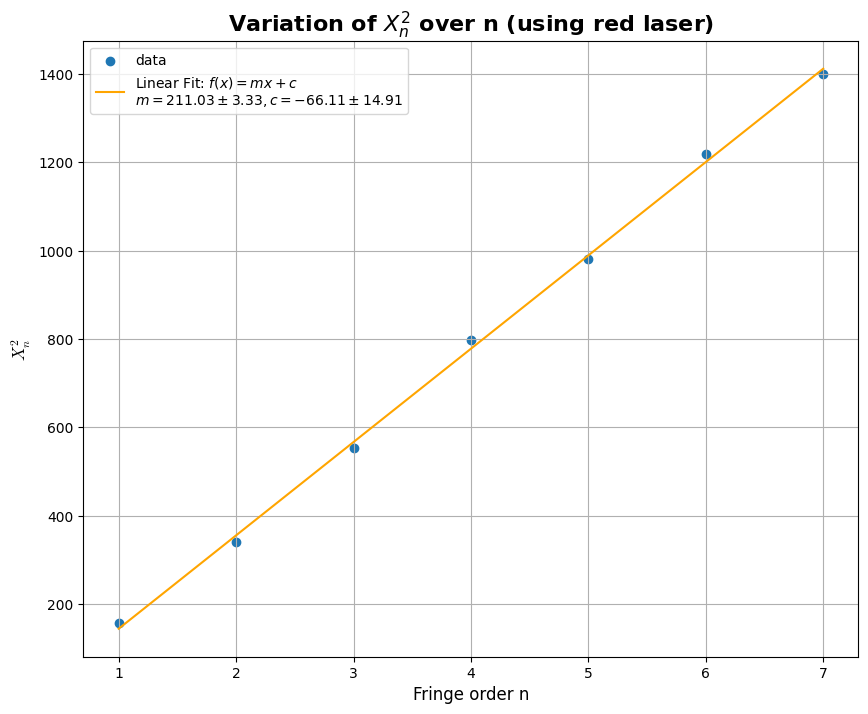

In [10]:
plt.figure(figsize = (10,8))
plt.scatter(n_arr,sqr_rad_arr, label = "data")
params, pcov = curve_fit(stLine,n_arr,sqr_rad_arr)
perr = np.sqrt(np.diag(pcov))
plt.plot(
    n_arr,
    stLine(n_arr, *params),
    color='orange',
    label=(
        f"Linear Fit: $f(x)=mx+c$\n"
        f"$m = {params[0]:.2f} \\pm {perr[0]:.2f}, "
        f"c = {params[1]:.2f} \\pm {perr[1]:.2f}$"
    )
)
plt.xlabel("Fringe order n",math_fontfamily='cm',fontsize = 12)
plt.ylabel(r"$X_n^2$",math_fontfamily='cm',fontsize = 12)
plt.title(r"Variation of $X_n^2$ over n (using red laser)",fontsize = 16 , fontweight= 'bold')
plt.legend(loc = "best")
plt.grid(True)
plt.savefig('Plot2.pdf', bbox_inches='tight', dpi=500)
plt.show()

In [6]:
delta_arr = np.arange(-2*np.pi, 4*np.pi, 0.01)

In [7]:
T_arr = 0.899803536/(1 + (4*(29.74207927**2)/(np.pi**2))*(np.sin(delta_arr/2))**2)

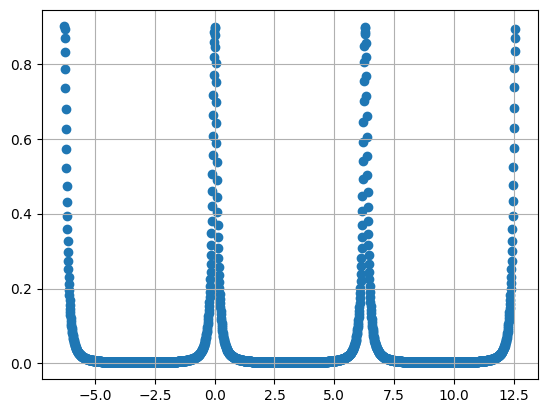

In [8]:
plt.figure()
plt.scatter(delta_arr,T_arr)
plt.grid(True)
plt.show()

3.2921151362322405


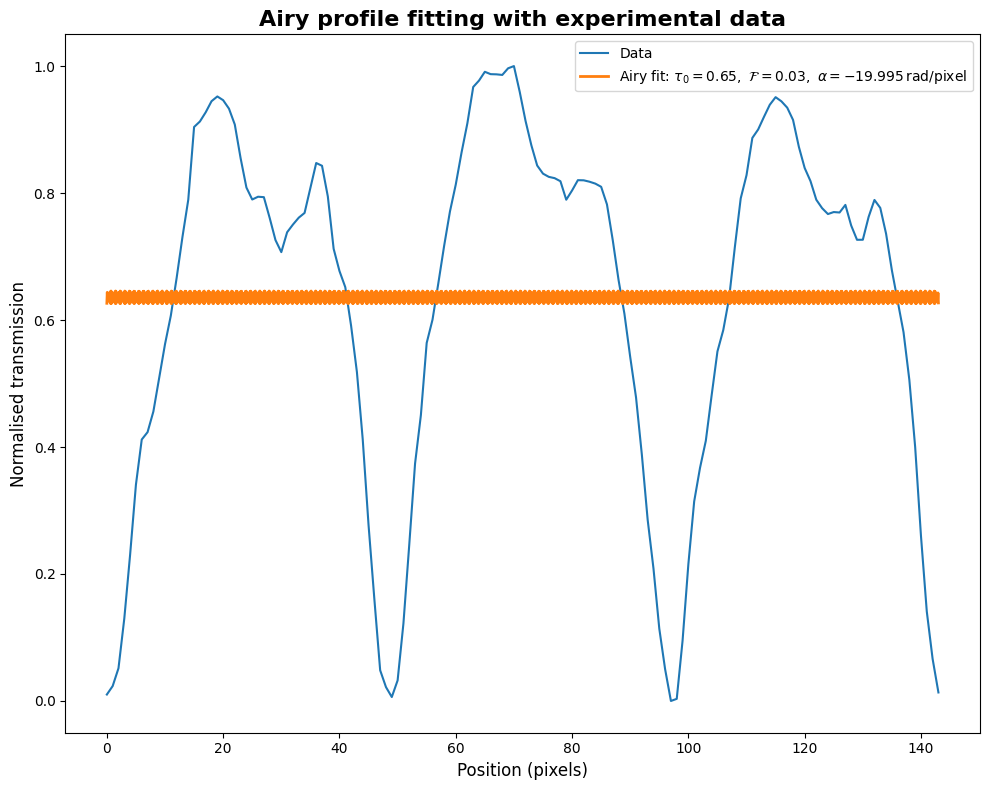

tau0      = 0.646
Finesse   = 0.03
alpha     = -19.9950 rad/pixel
Phase     = 11.179 rad
[0.042838   0.11183077 0.04140398 3.42823712]


In [80]:
df = pd.read_csv("Plot Values 12.csv")  
x = df.iloc[:, 0].values               # pixel coordinate
y = df.iloc[:, 1].values

print(y.max()/y.min())
# normalise intensity
y = y - y.min()
y = y / y.max()

# use central region only
# mask = (x > 0.15*x.max()) & (x < 0.85*x.max())
# x_fit = x[mask]
# y_fit = y[mask]
x_fit = x
y_fit = y

# # Airy function
# def airy_profile(x, tau0, finesse, alpha, phi):
#     return tau0 / (
#         1 + (4*finesse**2/np.pi**2) * np.sin(alpha*x + phi)**2
#     )

# # guesses
# p0 = [1.0, 3.0, 0.06, 0.0]
def airy_profile(x, tau0, F, alpha, phi):
    return tau0 / (1 + F * np.sin(alpha*x + phi)**2)

# Initial guesses
p0 = [
    1.1,     # tau0
    5,     # F (Airy coefficient, NOT finesse)
    -20,    # alpha
    12      # phi
]
params, cov = curve_fit(
    airy_profile,
    x_fit,
    y_fit,
    p0=p0,
    # bounds=([0.5, 0, 0, -np.pi], [1.5, 50, 1, np.pi]),
    maxfev=300000
)

tau0, finesse, alpha, phi = params

# smooth fit
x_dense = np.linspace(x_fit.min(), x_fit.max(), 2000)
y_dense = airy_profile(x_dense, *params)
perr = np.sqrt(np.diag(cov))
fit_label = (
    r"Airy fit: "
    rf"$\tau_0={tau0:.2f},\ "
    rf"\mathcal{{F}}={finesse:.2f},\ "
    rf"\alpha={alpha:.3f}\,\mathrm{{rad/pixel}}$"
)

# plot
plt.figure(figsize=(10,8))
plt.plot(x, y,label="Data")
plt.plot(x_dense, y_dense, label=fit_label, linewidth=2)
plt.title("Airy profile fitting with experimental data",fontsize = 16 , fontweight= 'bold')
plt.xlabel("Position (pixels)",fontsize = 12)
plt.ylabel("Normalised transmission", fontsize = 12)
plt.legend(loc = "best")
plt.tight_layout()
plt.savefig('Plot3.pdf', bbox_inches='tight', dpi=500)
plt.show()

# results
print(f"tau0      = {tau0:.3f}")
print(f"Finesse   = {finesse:.2f}")
print(f"alpha     = {alpha:.4f} rad/pixel")
print(f"Phase     = {phi:.3f} rad")
print(perr)

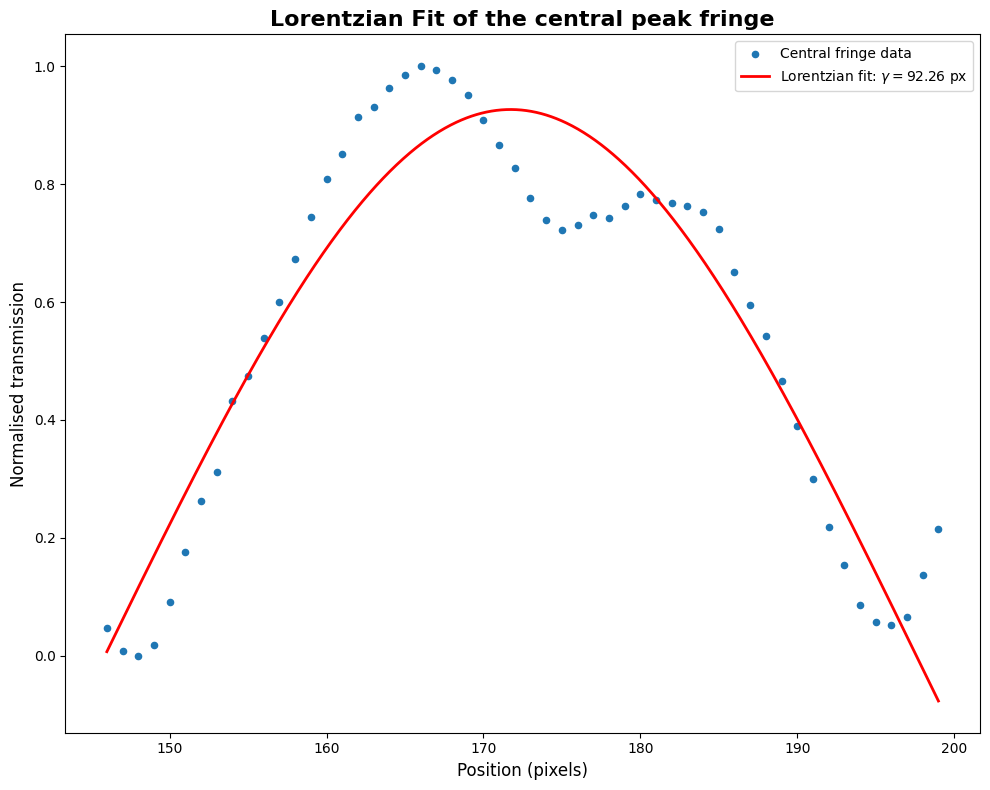

===== Lorentzian fit (central fringe) =====
Peak position x0 = 171.73 pixels
FWHM Γ = 92.26 pixels
Amplitude A = 1122.621
Background C = -2.947
[1.03912684e+03 3.66713249e-01 3.34763995e+01 2.19779861e+00]


In [65]:
# Load data
df = pd.read_csv("Plot Values 8.csv")
x = df.iloc[:, 0].values
y = df.iloc[:, 1].values

# Normalise
y = y - y.min()
y = y / y.max()

# Select central fringe region (adjustable)
mask = (x > 145) & (x < 200)
x_c = x[mask]
y_c = y[mask]

# Lorentzian function
def lorentzian(x, A, x0, gamma, C):
    return A/(np.pi*gamma) / (1 + ((x - x0)/(gamma/2))**2) + C

# Initial guesses
A0 = y_c.max() - y_c.min()
x0_0 = x_c[np.argmax(y_c)]
gamma0 = (x_c.max() - x_c.min()) / 5
C0 = y_c.min()

p0 = [A0, x0_0, gamma0, C0]

params, cov = curve_fit(lorentzian, x_c, y_c, p0=p0, maxfev=20000)
A, x0, gamma, C = params

# Fitted curve
x_dense = np.linspace(x_c.min(), x_c.max(), 1000)
y_dense = lorentzian(x_dense, *params)
perr = np.sqrt(np.diag(cov))
# Plot
plt.figure(figsize=(10,8))
plt.scatter(x_c, y_c, s=20, label="Central fringe data")
plt.plot(x_dense, y_dense, color="red", linewidth=2,
         label=rf"Lorentzian fit: $\gamma={gamma:.2f}$ px")
plt.title("Lorentzian Fit of the central peak fringe",fontsize = 16 , fontweight= 'bold')
plt.xlabel("Position (pixels)",fontsize = 12)
plt.ylabel("Normalised transmission",fontsize = 12)
plt.legend(loc = "best")
plt.tight_layout()
plt.savefig('Plot4.pdf', bbox_inches='tight', dpi=500)
plt.show()

# Results
print("===== Lorentzian fit (central fringe) =====")
print(f"Peak position x0 = {x0:.2f} pixels")
print(f"FWHM Γ = {gamma:.2f} pixels")
print(f"Amplitude A = {A:.3f}")
print(f"Background C = {C:.3f}")
print(perr)